<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/Actividad5Preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---

*   NOMBRE: JOSEGREG DE JESUS TOVAR BLANCO
*   MATRÍCULA: A01840476

En esta actividad trabajarás con el archivo `heart_disease.csv`, basado en un conjunto de datos sobre pacientes y variables clínicas relacionadas con enfermedades cardíacas, disponible en Kaggle.

Los datos fueron recopilados para analizar la presencia de enfermedades cardíacas en los pacientes y contienen información demográfica, clínica y resultados de pruebas diagnósticas. Los indicadores incluidos son:

* `id`: Identificador único de cada paciente
* `age`: Edad del paciente en años
* `origin`: Lugar de estudio
* `sex`: Masculino / Femenino
* `cp`: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático)
* `trestbps`: Presión arterial en reposo (en mm Hg al ingreso al hospital)
* `chol`: Colesterol sérico en mg/dl
* `fbs`: Si el azúcar en ayunas > 120 mg/dl
* `restecg`: Resultados del electrocardiograma en reposo (normal, anomalía ST-T, hipertrofia ventricular izquierda)
* `thalach`: Frecuencia cardíaca máxima alcanzada
* `exang`: Angina inducida por ejercicio (Verdadero / Falso)
* `oldpeak`: Depresión del segmento ST inducida por ejercicio respecto al reposo
* `slope`: Pendiente del segmento ST en el pico de ejercicio
* `ca`: Número de vasos principales coloreados por fluoroscopía (0 - 3)
* `thal`: Resultado de la prueba de perfusión cardíaca (normal, defecto fijo, defecto reversible)
* `num`: Indica si el paciente tiene o no enfermedad cardíaca, o el grado de enfermedad (0 = sano, 1 - 4 = enfermedad) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cardio_df = pd.read_csv("/content/drive/MyDrive/ACTIVIDAD 5/heart_disease (1).csv")

1. Descarga el archivo: `heart_disease.csv` y guarda, en un dataframe (`cardio_df`), todos sus registros.
* Haz que la columna `id` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.

In [4]:
# Hacemos de ID el el indice

cardio_df.set_index("id", inplace=True)

#contamos tipos de datos

cardio_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   origin    918 non-null    object 
 3   cp        918 non-null    object 
 4   trestbps  859 non-null    float64
 5   chol      888 non-null    float64
 6   fbs       829 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    863 non-null    float64
 9   exang     863 non-null    object 
 10  oldpeak   856 non-null    float64
 11  slope     610 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       918 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 114.8+ KB


In [5]:
#Contar los tipos de datos

num_cols = cardio_df.select_dtypes(include=["int64","float64"]).columns
cat_cols = cardio_df.select_dtypes(include=["object"]).columns

print("Columnas Numéricas:", len(num_cols))
print("Columnas de Texto:", len(cat_cols))

Columnas Numéricas: 7
Columnas de Texto: 8


In [6]:
# Cantidad de valore únicos por columna

cardio_df.nunique().sort_values()


,0
sex,2
fbs,2
exang,2
restecg,3
slope,3
thal,3
cp,4
origin,4
ca,4
num,5


2. Examina las variables numéricas que presentan pocos valores únicos, ya que esto puede indicar que en realidad se tratan de variables categóricas codificadas como números.
* Si existen casos de este tipo, conviértelas a categóricas. Antes de hacerlo, revisa sus descripciones para determinar si son ordinales o nominales y, si son ordinales, establece el orden correcto de las categorías.

En este caso usaré un poco de criterio para la conversión de las variables, partamos del resumen:

| Variable | Valores únicos esperados | Tipo real                  |
| -------- | ------------------------ | -------------------------- |
| sex      | 2                        | Nominal                    |
| fbs      | 2                        | Nominal                    |
| exang    | 2                        | Nominal                    |
| cp       | 4                        | Nominal                    |
| restecg  | 3                        | Nominal                    |
| slope    | 3                        | Ordinal (asumiendo orden de down a upper)                   |
| ca       | 4                        | Ordinal                    |
| thal     | 3                        | Nominal                    |
| num      | 5                        | Ordinal (grado enfermedad) |


### Primero Creemos un grupo de Variables Nominales

In [8]:
#Convirtamos las nominales
#hagamos un grupo

variables_nominales = ["sex", "fbs", "exang", "cp", "restecg", "thal"]

for col in variables_nominales:
    cardio_df[col] = cardio_df[col].astype("category")


### Luego trabajemos las variables Ordinales

**Slope**

1 = upsloping

2 = flat

3 = downsloping

In [10]:
cardio_df["slope"] = cardio_df["slope"].str.strip()
#mapping de variables

slope_map = {
    "downsloping": 1,
    "flat": 2,
    "upsloping": 3
}

cardio_df["slope_cat"] = cardio_df["slope"].map(slope_map)
#Convertir a categorica pero creando una columna nueva para el manejo EDA

cardio_df["slope_cat"] = pd.Categorical(
    cardio_df["slope_cat"],
    categories=[1,2,3],
    ordered=True
)




In [11]:
#comprobamos que vamos bien
display(
    cardio_df["slope_cat"]
    .value_counts(dropna=False)
    .to_frame(name="Frecuencia")
)


,Frecuencia
slope_cat,
2,345
NaN,308
3,202
1,63


**ca (número de vasos)**

0 < 1 < 2 < 3

In [13]:
cardio_df["ca"] = pd.Categorical(
    cardio_df["ca"],
    categories=[0,1,2,3],
    ordered=True
)


In [14]:
display(
    cardio_df["slope"]
    .value_counts(normalize=True, dropna=False)
    .to_frame(name="Proporción")
)


,Proporción
slope,
flat,0.375817
NaN,0.335512
upsloping,0.220044
downsloping,0.068627


**num (target)**

0 = sano

1 a 4 = grados de enfermedad

Ordinal porque tiene progresión y es ordenable

In [15]:
cardio_df["num"] = pd.Categorical(
    cardio_df["num"],
    categories=[0,1,2,3,4],
    ordered=True
)


3. Obtén las estadísticas descriptivas de las variables, realizando el análisis por separado para las variables numéricas y las categóricas.
* Para las numéricas, incluye el sesgo y la curtosis.
* Para las categóricas, imprime además las tablas de frecuencia.

In [19]:
# Separamos las variables numericas de las c ategoricas:

num_df = cardio_df.select_dtypes(include=["int64","float64"])
cat_df = cardio_df.select_dtypes(include=["category"])

#Hagamos el EDA para numericas


num_stats = num_df.describe().T
num_stats["skew"] = num_df.skew()
num_stats["kurtosis"] = num_df.kurt()
print(f"EDA Variables numericas \n")
display(num_stats)

#EDA para categoricas
cat_df.describe()
print("\n EDA Variables Categoricas \n")
for col in cat_df.columns:
    print(f"\nFrecuencias de {col}")

    tabla = (
        cardio_df[col]
        .value_counts(dropna=False)
        .reset_index()
    )

    tabla.columns = [col, "Frecuencia"]

    display(tabla)

for col in cat_df.columns:
    print(f"\nProporciones relativas de {col}")

    tabla = (
        cardio_df[col]
        .value_counts(normalize=True, dropna=False)
        .reset_index()
    )

    tabla.columns = [col, "Proporción"]

    display(tabla.style.format({"Proporción": "{:.2%}"}))





EDA Variables numericas 



,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,918.0,53.530501,9.412783,28.0,47.0,54.0,60.0,77.0,-0.193710,-0.382511
trestbps,859.0,132.294529,18.535875,80.0,120.0,130.0,140.0,200.0,0.630411,0.632992
chol,888.0,242.189189,53.424806,85.0,216.0,223.0,268.0,603.0,1.640672,6.573848
thalch,863.0,137.528389,25.950226,60.0,120.0,140.0,157.0,202.0,-0.209319,-0.483939
oldpeak,856.0,0.880607,1.091840,-2.6,0.0,0.5,1.5,6.2,1.037990,1.119834



 EDA Variables Categoricas 


Frecuencias de sex


,sex,Frecuencia
0,Male,724
1,Female,194



Frecuencias de cp


...

,thal,Proporción
0,nan,52.72%
1,normal,21.35%
2,reversable defect,20.92%
3,fixed defect,5.01%



Proporciones relativas de num


,num,Proporción
0,0,44.77%
1,1,28.65%
2,2,11.87%
3,3,11.66%
4,4,3.05%



Proporciones relativas de slope_cat


,slope_cat,Proporción
0,2,37.58%
1,nan,33.55%
2,3,22.00%
3,1,6.86%


4. Calcula el porcentaje de valores faltantes en cada columna.
* Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
* Crea un mapa de calor que visualice la distribución de los valores faltantes en todas las columnas restantes.
* Algunas variables presentan valores faltantes de manera simultánea; es decir, en el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo. Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.

In [20]:
#Porcentaje faltante:

faltante_pct = (
    cardio_df.isna()
    .mean() * 100
).sort_values(ascending=False)

display(faltante_pct.to_frame(name="Porcentaje Faltante"))


,Porcentaje Faltante
ca,66.339869
thal,52.723312
slope_cat,33.551198
slope,33.551198
fbs,9.694989
oldpeak,6.753813
trestbps,6.427015
exang,5.991285
thalch,5.991285
chol,3.267974


In [27]:
#Eliminamos columnas con mas de 30%
cols_to_drop = faltante_pct[faltante_pct > 30].index
cols_to_drop
cardio_df = cardio_df.drop(columns=cols_to_drop)


KeyError: "['ca', 'thal', 'slope_cat', 'slope'] not found in axis"

### Mapa de Calor de Faltantes

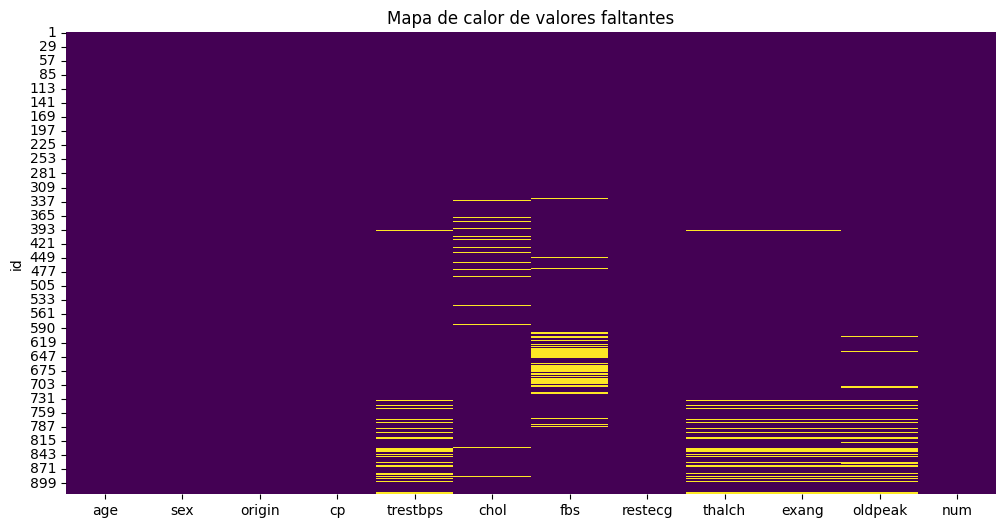

In [28]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cardio_df.isna(),
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de calor de valores faltantes")
plt.show()

In [29]:
#ahora buscamos columnas que tienen NAN al mismo tiempo en mismas filas

missing_matrix = cardio_df.isna()

co_missing = missing_matrix.corr()

display(co_missing)


,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,NaN,NaN,NaN,NaN,1.000000,0.026780,-0.070859,NaN,0.963267,0.963267,0.902999,NaN
chol,NaN,NaN,NaN,NaN,0.026780,1.000000,-0.060224,NaN,0.031047,0.031047,0.023776,NaN
fbs,NaN,NaN,NaN,NaN,-0.070859,-0.060224,1.000000,NaN,-0.082717,-0.082717,-0.029500,NaN
restecg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,NaN,NaN,NaN,NaN,0.963267,0.031047,-0.082717,NaN,1.000000,1.000000,0.919740,NaN
exang,NaN,NaN,NaN,NaN,0.963267,0.031047,-0.082717,NaN,1.000000,1.000000,0.919740,NaN


**Observación**

Baso mi analisis en la siguiente visualizacion de la tabla, partimos de entender:

| Valor Matriz      | Interpretación            |
| ---------- | ------------------------- |
| mayor que 0.7      | Faltan juntas fuertemente |
| 0.3 a 0.7  | Patron moderado           |
| -0.3 a 0.3 | Sin relación        |
| menor que -0.7     | Patron inverso fuerte     |

Se observa algo importante en las variables:

- thalach

- exang

- oldpeak

- trestbps

Todas están relacionadas con pruebas de esfuerzo o evaluación cardíaca avanzada y todas tienen correlaciones altas en missing. Lo cual puede sugerir:

1. Son pruebas que probablemente se realizaron juntas
2. Si una no se hizo, las demás tampoco
3. Intuiria que es una prueba de esfuerzo



5. Si centramos el análisis en una de las variables identificadas en el ejercicio anterior, se puede suponer que los hallazgos obtenidos podrían ser aplicables a las demás variables que presentan un patrón similar.

* ¿Tendrán los valores faltantes de `thalch` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
  *   Numéricas: `age`, `chol`
  *   Categóricas: `restecg`, `cp`

Para ello deberás dividir cada columna en dos grupos: con / sin faltantes en `thalch` y utilizar métodos gráficos y pruebas de hipótesis para ver si hay diferencias significativas.
* Incluye las conclusiones del análisis con los resultados obtenidos.
* Justifica si el mecanismo de faltantes de `thalch` es MCAR (*Missing Completely at Random*) o MAR (*Missing at Random*).

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

### Variables numéricas (age, chol)

In [33]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

In [34]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV,df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {}'.format(p_value))

In [36]:
print(cardio_df.columns)


Index(['age', 'sex', 'origin', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'num'],
      dtype='object')


In [37]:
#Veamos que esta perdido

BM_thalach = cardio_df["thalch"].isna()


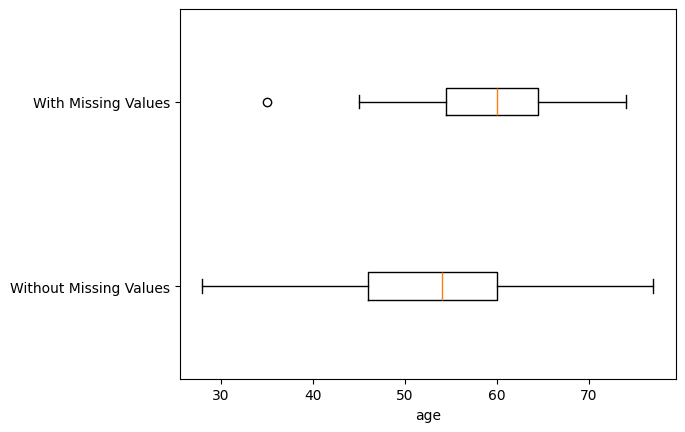

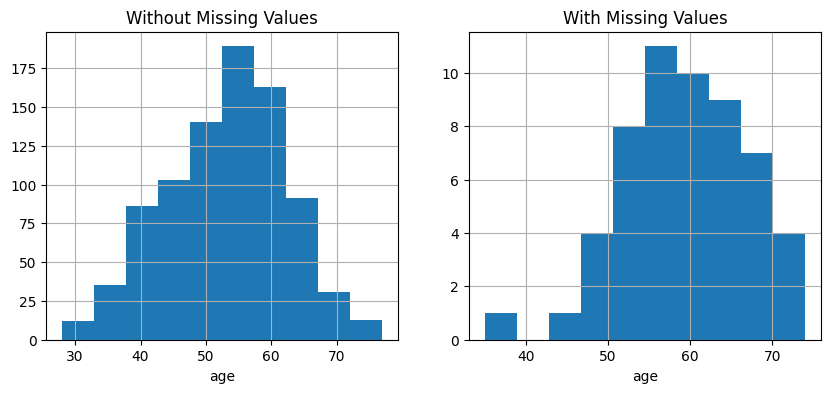

p-value of t-test: 1.5041244185890902e-06


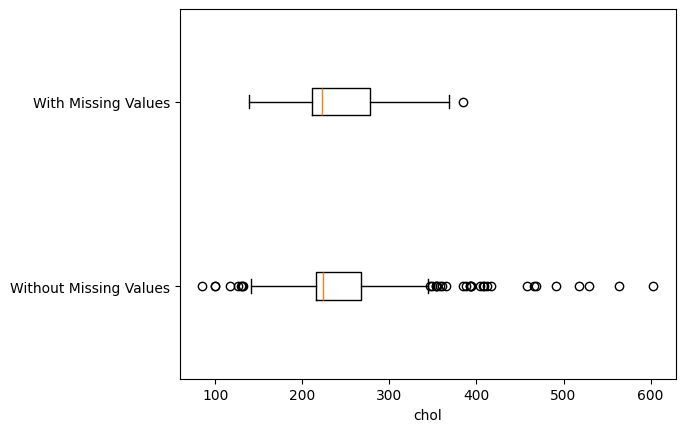

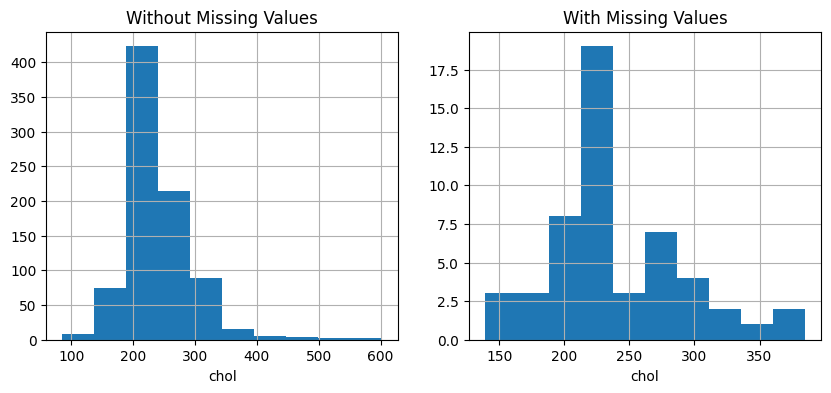

p-value of t-test: 0.7165289974295672


In [38]:
Diagnose_MV_Numerical(cardio_df, "age", BM_thalach)
Diagnose_MV_Numerical(cardio_df, "chol", BM_thalach)


**Conclusión para Edad y Colesterol**

El análisis comparativo entre los grupos con y sin valores faltantes en la variable thalach mostró una diferencia bien significativa en la variable age (p-value = 1.5041244185890902e-06) Este resultado indica que la distribución de edades no es equivalente entre ambos grupos, lo que sugiere que la ausencia de datos en thalach no ocurre de manera completamente aleatoria.

**Desde una perspectiva de data science**, esto implica que el mecanismo de generación de valores faltantes no cumple con el supuesto de MCAR (Missing Completely at Random) ya que la probabilidad de que un valor este ausente depende de una variable del dataset (edad). En contraste, la variable chol no presentó diferencias significativas entre grupos (p-value = 0.7165289974295672), lo que sugiere que el colesterol no está asociado con la ausencia de thalach.

Cuando al menos una variable observada está relacionada con el patrón de missing, el mecanismo más consistente con la evidencia es MAR (Missing At Random). Bajo MAR, la teoria nos dice que la probabilidad de que falte un dato depende de variables observadas pero no del valor faltante en si mismo.

**Desde el punto de vista clínico**, esta asociación puede tener coherencia médica. La frecuencia cardíaca máxima alcanzada (thalach) suele registrarse durante una prueba de esfuerzo. Es plausible que pacientes de mayor edad no hayan sido sometidos a dicha prueba, lo que explicaría la mayor proporción de valores faltantes en ciertos rango. Esto refuerza la interpretación de que el patrón de valores faltantes responde a una estructura del proceso de recolección de datos y no alatorieddad.

En consecuencia, el mecanismo de valores faltantes en thalach se clasifica como MAR, lo cual tiene implicaciones importantes para el preprocesamiento posterior, ya que la eliminación simple de registros podría introducir sesgo sistemático en el modelo.

In [41]:
# Para no quedarnos con la duda de las edades

cardio_df.groupby(BM_thalach)["age"].describe()


,count,mean,std,min,25%,50%,75%,max
thalch,,,,,,,,
False,863.0,53.155272,9.381029,28.0,46.0,54.0,60.0,77.0
True,55.0,59.418182,7.887381,35.0,54.5,60.0,64.5,74.0


Corroborado que a mayor edad no hace la prueba


### Variables categóricas (restecg, cp)

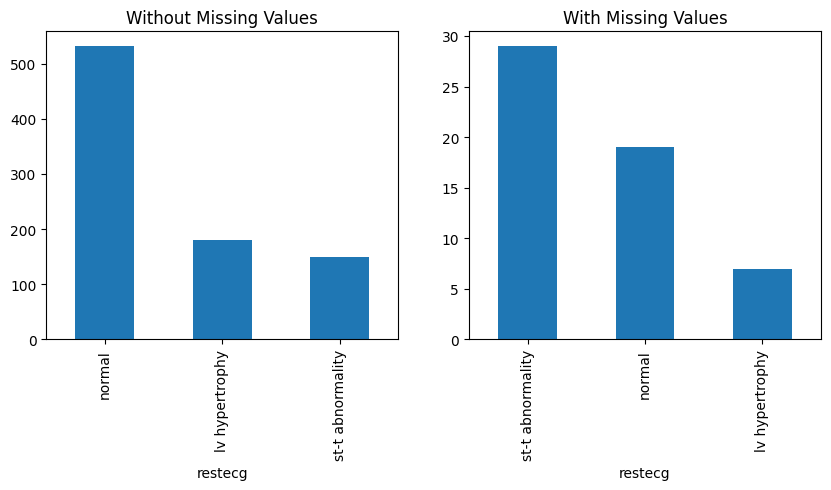

p-value of Chi_squared test: 1.1472889573985467e-09


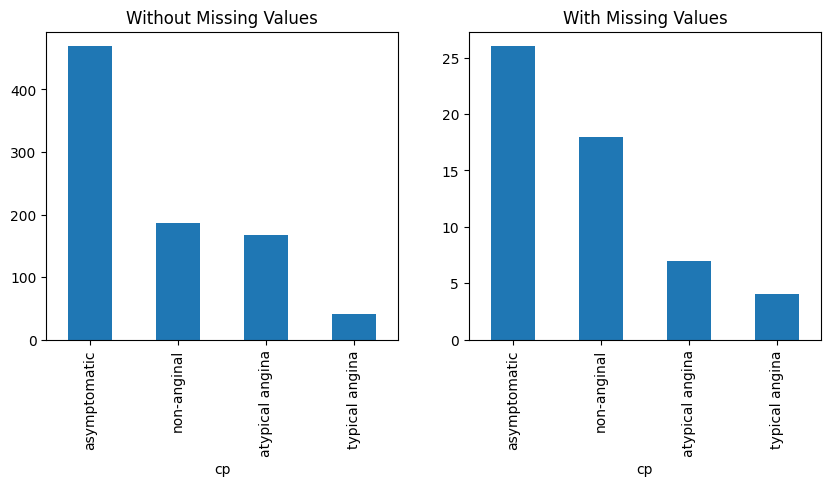

p-value of Chi_squared test: 0.15420097177251701


In [42]:
Diagnose_MV_Categorical(cardio_df, "restecg", BM_thalach)
Diagnose_MV_Categorical(cardio_df, "cp", BM_thalach)


**Conclusión para variables categoricas:**

El análisis de asociación entre la presencia de valores faltantes en thalach y las variables categóricas mostró resultados distintos: En el caso de restecg, la prueba chi-cuadrado arrojo un p-value altamente significativo (p < 0.05), lo que indica que existe una relación estadisticamente significativa entre el tipo de resultado del electrocardiograma en reposo y la probabilidad de que falte el valor de thalach. En contraste, la variable cp (tipo de dolor toracico) no presentó asociación significativa (p > 0.05), lo que sugiere que la ausencia de thalach no depende del tipo de dolor torácico reportado.

Desde la **perspectiva de data science**, estos resultados implican que el patrón de valores faltantes no es completamente aleatorio, ya que depende de al menos una variable observada del conjunto de datos (restecg). Esto descarta el mecanismo MCAR y es consistente con un mecanismo MAR, en el cual la probabilidad de que un dato esté ausente depende de información observada en el dataset.

Desde el **punto de vista clínico**, esta asociación es coherente, ya que el resultado del electrocardiograma en reposo puede influir en la decisión médica de realizar o no una prueba de esfuerzo, necesaria para medir la frecuencia cardíaca máxima. En cambio, el tipo de dolor torácico no parece condicionar de manera significativa la realización de dicha prueba en este conjunto de datos.

6. La imputación de una variable con valores faltantes puede realizarse por grupos o segmentos relevantes. Esto significa que, en lugar de utilizar una estadística global de toda la columna, se calcula la estadística correspondiente dentro de cada grupo definido por otra variable, haciendo:

> `df['var_with_missing'] = df.groupby('related_var')['var_with_missing'].transform(lambda x: x.fillna(x.median()))`

* Utiliza la variable `restecg` para separar los grupos e imputar `thalch` y todas las variables con patrón de faltantes similar (identificadas en el ejercicio 4) Asegúrate de cambiar la función de agregado si hay variables no numéricas.
* Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.

In [52]:
cardio_df.columns = cardio_df.columns.str.strip().str.lower()
BM_thalch = cardio_df["thalch"].isna()


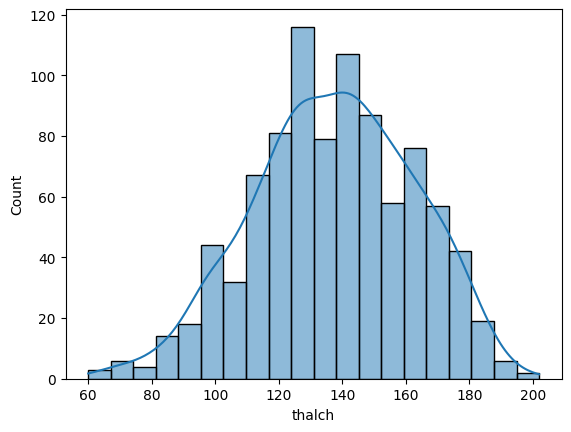

np.float64(-0.18970196745856902)

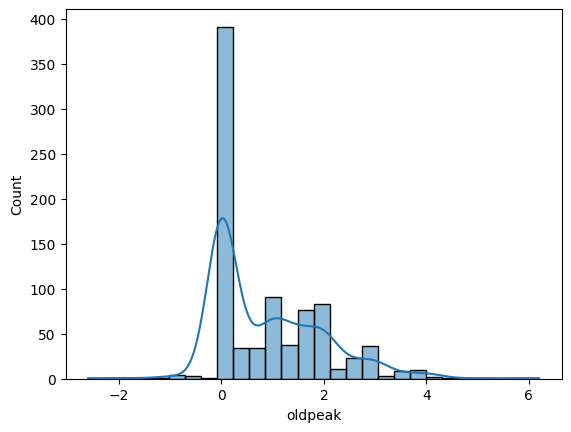

np.float64(1.0379904673527325)

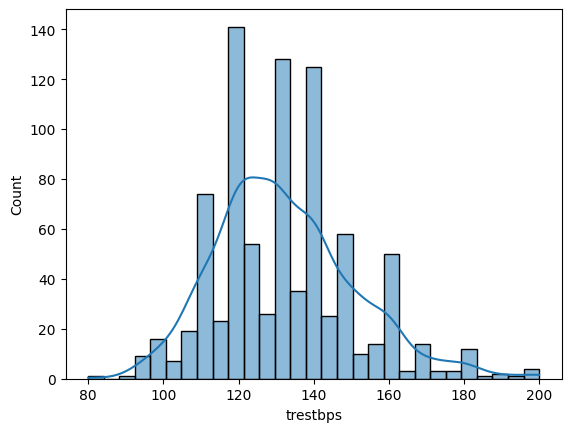

np.float64(0.6304108540023567)

In [58]:
#OK basandonos en restecg vamos a imputar thalch
#primero veamos que tipo de distribucipn tienen las variables para ver como rellenar

sns.histplot(cardio_df["thalch"].dropna(), kde=True)
plt.show()
display(cardio_df["thalch"].skew())

sns.histplot(cardio_df["oldpeak"].dropna(), kde=True)
plt.show()
display(cardio_df["oldpeak"].skew())

sns.histplot(cardio_df["trestbps"].dropna(), kde=True)
plt.show()
display(cardio_df["trestbps"].skew())



asi la decision por variable seria:

| Variable | Skew  | Decision recomendada   |
| -------- | ----- | ---------------------- |
| thalch   | -0.19 | Media                  |
| oldpeak  | 1.03  | Mediana                |
| trestbps | 0.63  | Mediana  |


In [60]:
cardio_df["thalch"] = (
    cardio_df
    .groupby("restecg", observed=True)["thalch"]
    .transform(lambda x: x.fillna(x.mean()))
)
cardio_df["oldpeak"] = (
    cardio_df
    .groupby("restecg", observed=True)["oldpeak"]
    .transform(lambda x: x.fillna(x.median()))
)
cardio_df["trestbps"] = (
    cardio_df
    .groupby("restecg", observed=True)["trestbps"]
    .transform(lambda x: x.fillna(x.median()))
)


In [61]:
#la categorica es facil esa por moda

cardio_df["exang"] = (
    cardio_df
    .groupby("restecg", observed=True)["exang"]
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))
)


### **Mapa de Calor **

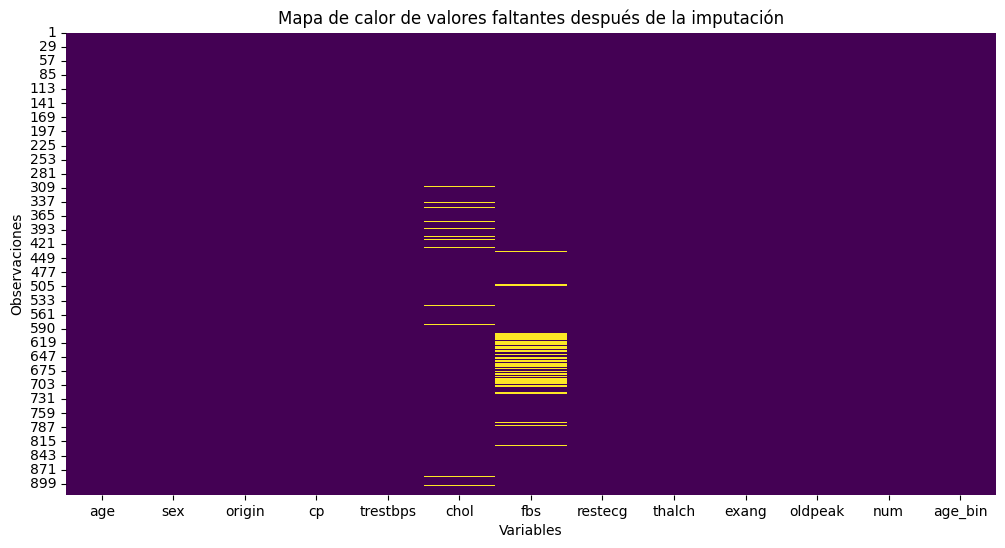

In [62]:
#De nuevo el mapa de Calor
plt.figure(figsize=(12,6))

sns.heatmap(
    cardio_df.isna(),   # matriz booleana de missing
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de calor de valores faltantes después de la imputación")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.show()

7. Para las variables que aún presentan valores faltantes, realiza la imputación utilizando estadísticas generales calculadas sobre toda la columna, sin segmentar por grupos. Esta vez utiliza la clase `SimpleImputer` de sklearn
* Justifica la estrategia (*mean, median, most_frequent*) que emplees en cada caso.


In [63]:
# de igual modo veamos la distribución
print("Skewness:", cardio_df["chol"].skew())
print("Mean:", cardio_df["chol"].mean())
print("Median:", cardio_df["chol"].median())
print("Mode:", cardio_df["chol"].mode()[0])


Skewness: 1.6406720078938555
Mean: 242.1891891891892
Median: 223.0
Mode: 223.0


**Análisis:**

Esto nos dice algo muy claro:

 La distribución de chol está fuertemente sesgada a la derecha.
La media está claramente desplazada hacia valores altos.
La mediana y la moda coinciden (223), lo cual sugiere concentración fuerte en esa zona.

- No deberías usar la media.
- La media estaría inflada por valores extremos
- La mediana es el estimador robusto adecuado

In [64]:
from sklearn.impute import SimpleImputer

imputer_chol = SimpleImputer(strategy="median")

cardio_df["chol"] = imputer_chol.fit_transform(
    cardio_df[["chol"]]
)


In [65]:
#FBS es categorica asi que es mas facil

imputer_fbs = SimpleImputer(strategy="most_frequent")

cardio_df["fbs"] = imputer_fbs.fit_transform(
    cardio_df[["fbs"]]
)


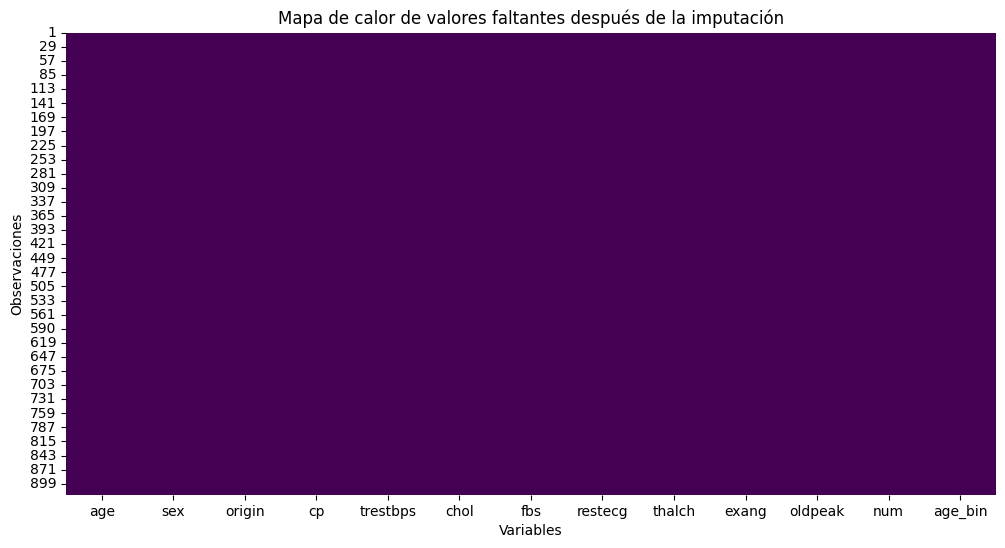

In [66]:
#De nuevo el mapa de Calor
plt.figure(figsize=(12,6))

sns.heatmap(
    cardio_df.isna(),   # matriz booleana de missing
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de calor de valores faltantes después de la imputación")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.show()

8. Dibuja boxplots de todas las variables numéricas.
* Obtén los valores atípicos mediante el método gráfico, a partir del objeto devuelto por el boxplot.

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak'], dtype='object')


/tmp/ipython-input-3182646151.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


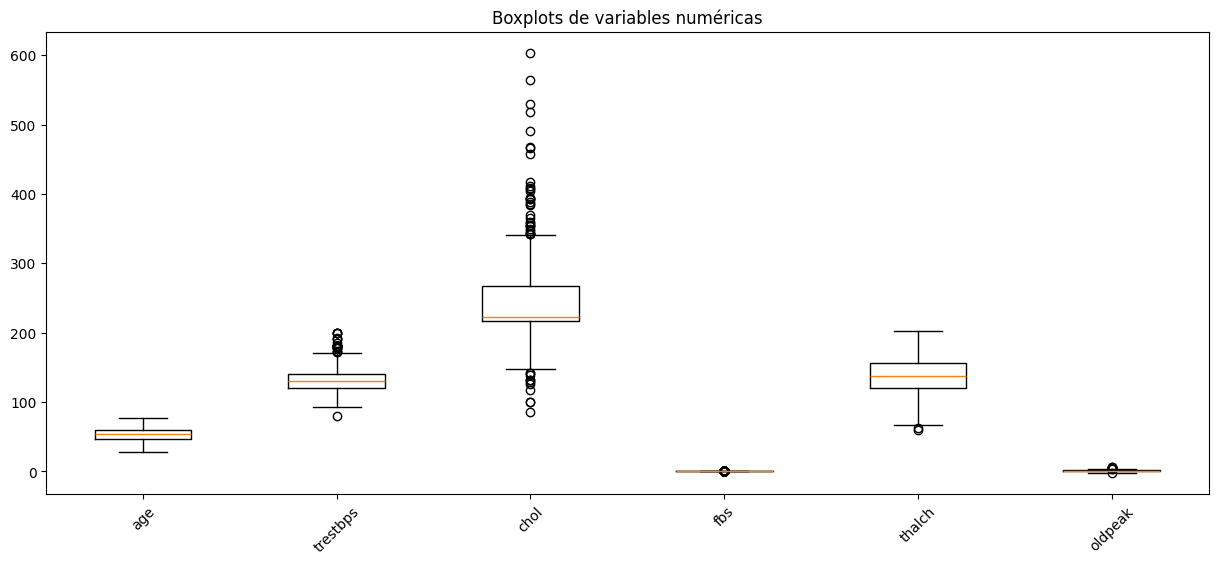

In [67]:
#identificar variables numericas

num_cols = cardio_df.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)

#dibujamos

plt.figure(figsize=(15,6))

box = plt.boxplot(
    [cardio_df[col].dropna() for col in num_cols],
    labels=num_cols,
    showfliers=True
)

plt.xticks(rotation=45)
plt.title("Boxplots de variables numéricas")
plt.show()


In [70]:
#eliminamos los outlyers

outliers_df = {}

for col in num_cols:
    Q1 = cardio_df[col].quantile(0.25)
    Q3 = cardio_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cardio_df[(cardio_df[col] < lower) | (cardio_df[col] > upper)][col]

    outliers_df[col] = outliers.values

outliers_df2 = (
    pd.DataFrame(
        [(col, val) for col, values in outliers_df.items() for val in values],
        columns=["Variable", "Valor atípico"]
    )
)

display(outliers_df2)

,Variable,Valor atípico
0,trestbps,172.0
1,trestbps,180.0
2,trestbps,200.0
3,trestbps,174.0
4,trestbps,178.0
...,...,...
222,oldpeak,-2.6
223,oldpeak,4.0
224,oldpeak,4.0
225,oldpeak,4.0


Se generaron boxplots para todas las variables numéricas con el fin de identificar valores atípicos mediante el criterio del rango intercuartílico (IQR) Los valores considerados atípicos corresponden a aquellos situados fuera del intervalo [Q1 − 1.5 por IQR, Q3 + 1.5por IQR]. Se extrajeron los valores atípicos directamente desde el objeto retornado por el método boxplot, permitiendo identificar qué variables presentan observaciones extremas potencialmente influyentes.

9. Para la variable `trestbps`, calcula los valores atípicos utilizando el método del rango intercuartílico (IQR).
* Para ello obtén los cuartiles necesarios y determina los límites superior e inferior para filtrar los valores que se encuentren fuera de ese rango.
* Verifica si los resultados coinciden con los obtenidos en el ejercicio anterior.

In [71]:
#Cuatiles

Q1 = cardio_df["trestbps"].quantile(0.25)
Q3 = cardio_df["trestbps"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 120.0
Q3: 140.0
IQR: 20.0


In [72]:
#limites

lower_limite = Q1 - 1.5 * IQR
upper_limite = Q3 + 1.5 * IQR

print("Límite inferior:", lower_limite)
print("Límite superior:", upper_limite)


Límite inferior: 90.0
Límite superior: 170.0


In [74]:
#filtrar valores

outliers_trestbps = cardio_df[
    (cardio_df["trestbps"] < lower_limite) |
    (cardio_df["trestbps"] > upper_limite)
]["trestbps"]

print("Cantidad de outliers:", len(outliers_trestbps))



Cantidad de outliers: 27


In [76]:
#comparamos
set(outliers_trestbps.values) == set(outliers_df["trestbps"])


True

10. Elimina los valores atípicos identificados de la variable `trestbps`.
* Dibuja el boxplot final para visualizar la distribución depurada.

In [77]:
#eliminamos

cardio_df_clean = cardio_df[
    (cardio_df["trestbps"] >= lower_limite) &
    (cardio_df["trestbps"] <= upper_limite)
]

print("Observaciones originales:", len(cardio_df))
print("Observaciones después de eliminar outliers:", len(cardio_df_clean))
print("Observaciones eliminadas:", len(cardio_df) - len(cardio_df_clean))



Observaciones originales: 918
Observaciones después de eliminar outliers: 891
Observaciones eliminadas: 27


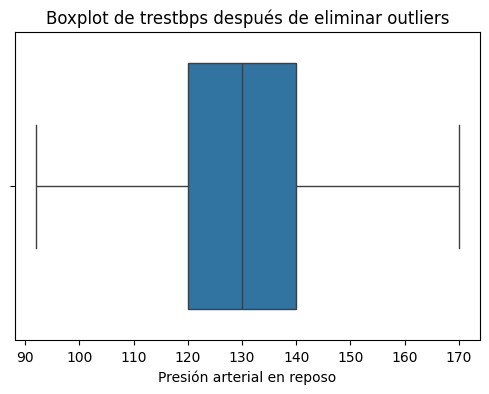

In [78]:
#otro plot

plt.figure(figsize=(6,4))

sns.boxplot(x=cardio_df_clean["trestbps"])

plt.title("Boxplot de trestbps después de eliminar outliers")
plt.xlabel("Presión arterial en reposo")
plt.show()


Se identificaron los valores atípicos de la variable trestbps utilizando el criterio del rango intercuartílico (IQR). Posteriormente, se eliminaron aquellas observaciones que se encontraban fuera de los límites establecidos por Q1 1.5 por IQR y Q3 + 1.5 por IQR. Finalmente, se generó un nuevo boxplot para visualizar la distribución depurada, observándose una reducción en la dispersión extrema y una distribución más compacta de la variable